# Telco Customer Churn Analysis
This notebook performs an end-to-end analysis of the Telco Customer Churn dataset: data loading, cleaning, EDA, feature engineering, and modeling.
Author: Notebook generated/updated to include descriptive markdown cells.

## Standard imports
This cell imports commonly used Python libraries for data analysis and visualization: NumPy, pandas, seaborn, matplotlib, and scikit-learn datasets.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets



In [2]:
from pathlib import Path

# Load data
fname = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
candidates = [
    Path("Ds_project1") / "Dataset" / fname,
    Path("..") / "Dataset" / fname,
    Path("Dataset") / fname,
    Path.cwd() / "Ds_project1" / "Dataset" / fname,
]
for p in candidates:
    if p.exists():
        path = p
        break
else:
    raise FileNotFoundError(f"Could not find {fname} in expected locations: {candidates}")

df = pd.read_csv(path)
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded data shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [4]:
#monthly charges
#total charges
# ===== STEP 1: DATA CLEANING =====
# Select key features
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'PaymentMethod', 'InternetService', 'Churn']
service_cols = ['OnlineSecurity', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df_clean = df[key_features + service_cols].copy()

# Convert TotalCharges to numeric (some may be blank strings)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Check missing values
print("\nMissing values before cleaning:")
print(df_clean.isnull().sum())

# Handle missing TotalCharges
if df_clean['TotalCharges'].isna().any():
    df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(
        df_clean['MonthlyCharges'] * df_clean['tenure']
    )

# Convert Churn to binary (1 = Yes, 0 = No)
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Create "Number of Services" feature
# Count how many services a customer has (Yes = 1, No = 0)
for col in service_cols:
    df_clean[col] = (df_clean[col] == 'Yes').astype(int)

df_clean['NumServices'] = df_clean[service_cols].sum(axis=1)

# Encode categorical variables: Contract, PaymentMethod, InternetService
df_clean['Contract'] = df_clean['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_clean['InternetService'] = df_clean['InternetService'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})
df_clean['PaymentMethod'] = pd.factorize(df_clean['PaymentMethod'])[0]  # Auto-encode remaining unique values

# Final dataset: keep only the target and key features
df_final = df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
                      'PaymentMethod', 'InternetService', 'NumServices', 'Churn']].copy()

print("\n✓ Data Cleaning Complete")
print(f"Final dataset shape: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
print(f"\nTarget distribution (Churn):")
print(df_final['Churn'].value_counts())
print(f"\nFirst few rows:")
display(df_final.head())


Missing values before cleaning:
tenure               0
MonthlyCharges       0
TotalCharges        11
Contract             0
PaymentMethod        0
InternetService      0
Churn                0
OnlineSecurity       0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
dtype: int64

✓ Data Cleaning Complete
Final dataset shape: (7043, 8)
Missing values: 0

Target distribution (Churn):
Churn
0    5174
1    1869
Name: count, dtype: int64

First few rows:


,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,NumServices,Churn
0,1,29.85,29.85,0,0,0,0,0
1,34,56.95,1889.50,1,1,0,2,0
2,2,53.85,108.15,0,1,0,1,1
3,45,42.30,1840.75,1,2,0,3,0
4,2,70.70,151.65,0,0,1,0,1


In [5]:
# ===== ENCODING MAPPINGS =====
# To understand the encoding, let's recreate and display the mappings

print("=" * 60)
print("ENCODING MAPPINGS")
print("=" * 60)

# Contract mapping
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
print("\n1. Contract Type:")
for key, val in contract_map.items():
    print(f"   {key} → {val}")

# InternetService mapping
internet_map = {'DSL': 0, 'Fiber optic': 1, 'No': 2}
print("\n2. Internet Service:")
for key, val in internet_map.items():
    print(f"   {key} → {val}")

# PaymentMethod mapping (auto-encoded by factorize)
payment_methods = df['PaymentMethod'].unique()
payment_map = {method: i for i, method in enumerate(sorted(payment_methods))}
print("\n3. Payment Method (factorized):")
for method, code in sorted(payment_map.items(), key=lambda x: x[1]):
    print(f"   {method} → {code}")

# Store mapping for reference
encoding_info = {
    'Contract': contract_map,
    'InternetService': internet_map,
    'PaymentMethod': payment_map
}

print("\n" + "=" * 60)

ENCODING MAPPINGS

1. Contract Type:
   Month-to-month → 0
   One year → 1
   Two year → 2

2. Internet Service:
   DSL → 0
   Fiber optic → 1
   No → 2

3. Payment Method (factorized):
   Bank transfer (automatic) → 0
   Credit card (automatic) → 1
   Electronic check → 2
   Mailed check → 3



In [6]:
# ===== STEP 2: EXPLORATORY DATA ANALYSIS (EDA) =====
print("\n" + "=" * 60)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Basic statistics
print("\nDataset Summary Statistics:")
display(df_final.describe())



STEP 2: EXPLORATORY DATA ANALYSIS

Dataset Summary Statistics:


,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,NumServices,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,0.690473,1.315633,0.872923,1.693029,0.265370
std,24.559481,30.090047,2266.794470,0.833755,1.148907,0.737796,1.595058,0.441561
min,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,35.500000,398.550000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,70.350000,1394.550000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,55.000000,89.850000,3786.600000,1.000000,2.000000,1.000000,3.000000,1.000000
max,72.000000,118.750000,8684.800000,2.000000,3.000000,2.000000,5.000000,1.000000


In [7]:
# ===== PIVOT TABLES =====
print("\n" + "=" * 60)
print("PIVOT TABLES: Churn by Key Features")
print("=" * 60)

# Prepare display-friendly labels
# Defines Mapping for contracts
contract_reverse = {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}

# Defines Mapping for Internet Service
internet_reverse = {0: 'DSL', 1: 'Fiber optic', 2: 'No'}

# Defines Mapping for Payment Method using Dictionary comprehension
if isinstance(encoding_info.get('PaymentMethod'), dict):
    payment_reverse = {v: k for k, v in encoding_info['PaymentMethod'].items()}
else:
    payment_reverse = {}

# Actual mapping
df_display = df_final.copy()
df_display['Contract'] = df_display['Contract'].map(contract_reverse)

df_display['InternetService'] = df_display['InternetService'].map(internet_reverse)
if payment_reverse:
    df_display['PaymentMethod'] = df_display['PaymentMethod'].map(payment_reverse)

# Tenure bins
df_display['TenureGroup'] = pd.cut(df_display['tenure'], bins=[0,6,12,24,72], labels=['0-6 mo','7-12 mo','13-24 mo','25+ mo'])

# 1) Churn by Contract
pivot_contract = df_display.groupby('Contract').agg(
    Customers=('Churn','count'),
    Churners=('Churn','sum'),
    ChurnRate=('Churn','mean'),
    AvgMonthly=('MonthlyCharges','mean'),
    AvgTotal=('TotalCharges','mean')
).sort_values('ChurnRate', ascending=False)
print('\n1) Churn by Contract')
display(pivot_contract.style.format({ 'ChurnRate':'{:.2%}', 'AvgMonthly':'${:,.2f}', 'AvgTotal':'${:,.2f}' }))

# 2) Churn by Payment Method
if 'PaymentMethod' in df_display.columns:
    pivot_payment = df_display.groupby('PaymentMethod').agg(
        Customers=('Churn','count'),
        Churners=('Churn','sum'),
        ChurnRate=('Churn','mean'),
        AvgMonthly=('MonthlyCharges','mean')
    ).sort_values('ChurnRate', ascending=False)
    print('\n2) Churn by Payment Method')
    display(pivot_payment.style.format({ 'ChurnRate':'{:.2%}', 'AvgMonthly':'${:,.2f}' }))

# 3) Churn by Internet Service
pivot_internet = df_display.groupby('InternetService').agg(
    Customers=('Churn','count'),
    Churners=('Churn','sum'),
    ChurnRate=('Churn','mean'),
    AvgMonthly=('MonthlyCharges','mean')
).sort_values('ChurnRate', ascending=False)
print('\n3) Churn by Internet Service')
display(pivot_internet.style.format({ 'ChurnRate':'{:.2%}', 'AvgMonthly':'${:,.2f}' }))

# 4) Churn by Tenure Group
pivot_tenure = df_display.groupby('TenureGroup').agg(
    Customers=('Churn','count'),
    Churners=('Churn','sum'),
    ChurnRate=('Churn','mean'),
    AvgMonthly=('MonthlyCharges','mean')
).sort_index()
print('\n4) Churn by Tenure Group')
display(pivot_tenure.style.format({ 'ChurnRate':'{:.2%}', 'AvgMonthly':'${:,.2f}' }))

# 5) Churn by Number of Services
pivot_services = df_display.groupby('NumServices').agg(
    Customers=('Churn','count'),
    Churners=('Churn','sum'),
    ChurnRate=('Churn','mean'),
    AvgMonthly=('MonthlyCharges','mean')
).sort_index()
print('\n5) Churn by Number of Services')
display(pivot_services.style.format({ 'ChurnRate':'{:.2%}', 'AvgMonthly':'${:,.2f}' }))

# 6) Cross pivot: Contract x InternetService (churn rate)
cross_pivot = pd.pivot_table(df_display, index='Contract', columns='InternetService', values='Churn', aggfunc='mean')
print('\n6) Churn Rate — Contract x InternetService')
display(cross_pivot.style.format('{:.2%}'))

print('\n✓ Pivot tables created')


PIVOT TABLES: Churn by Key Features

1) Churn by Contract


,Customers,Churners,ChurnRate,AvgMonthly,AvgTotal
Contract,,,,,
Month-to-month,3875,1655,42.71%,$66.40,"$1,369.25"
One year,1473,166,11.27%,$65.05,"$3,032.62"
Two year,1695,48,2.83%,$60.77,"$3,706.93"



2) Churn by Payment Method


,Customers,Churners,ChurnRate,AvgMonthly
PaymentMethod,,,,
Bank transfer (automatic),2365,1071,45.29%,$76.26
Credit card (automatic),1612,308,19.11%,$43.92
Electronic check,1544,258,16.71%,$67.19
Mailed check,1522,232,15.24%,$66.51



3) Churn by Internet Service


...


5) Churn by Number of Services


,Customers,Churners,ChurnRate,AvgMonthly
NumServices,,,,
0,2428,557,22.94%,$35.35
1,1110,472,42.52%,$67.37
2,1263,394,31.20%,$75.97
3,1095,291,26.58%,$85.32
4,732,126,17.21%,$90.40
5,415,29,6.99%,$96.28



6) Churn Rate — Contract x InternetService


InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22%,54.61%,18.89%
One year,9.30%,19.29%,2.47%
Two year,1.91%,7.23%,0.78%



✓ Pivot tables created


### Visualizations: EDA plots
This cell creates four summary plots: churn by tenure, churn by contract type, monthly charges distributions by churn, and a correlation heatmap.

/tmp/ipykernel_13318/3363972937.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df_final.groupby(pd.cut(df_final['tenure'], bins=5))['Churn'].agg(['sum', 'count', 'mean'])


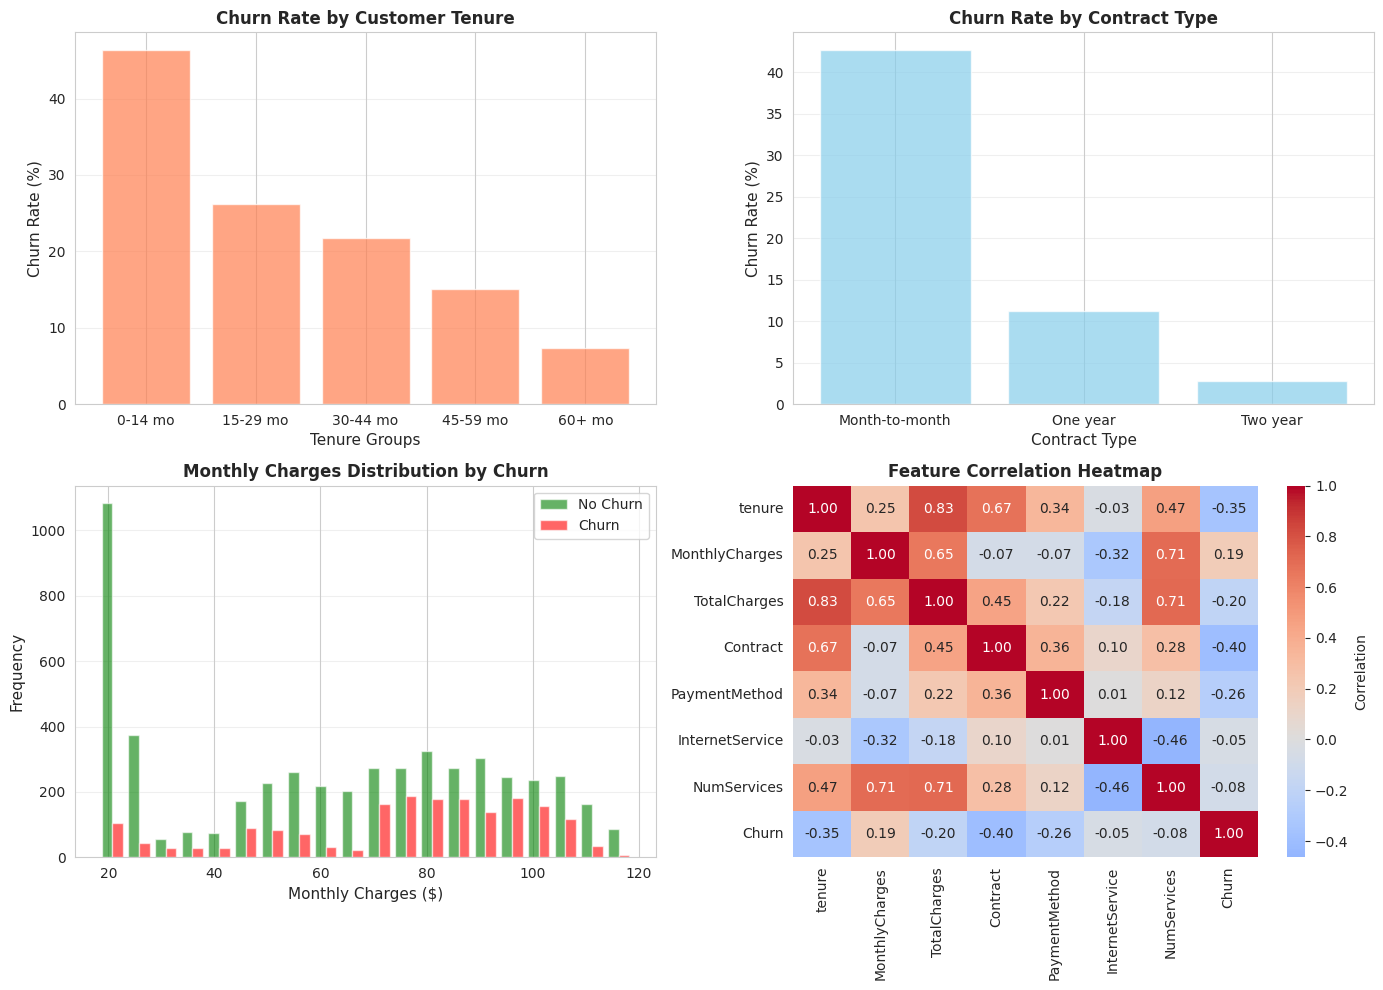


✓ EDA Complete


In [8]:
# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create a figure with subplots for key analyses
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Do customers with short tenure churn more?
ax1 = axes[0, 0]
#Groups by tenure to 5bins and calculates the churn rate by aggregating each bin's sum, count, and mean.
churn_by_tenure = df_final.groupby(pd.cut(df_final['tenure'], bins=5))['Churn'].agg(['sum', 'count', 'mean'])
tenure_labels = ['0-14 mo', '15-29 mo', '30-44 mo', '45-59 mo', '60+ mo']
# Creates the bar plot
ax1.bar(tenure_labels, churn_by_tenure['mean'] * 100, color='coral', alpha=0.7)

# Axes labels and title
ax1.set_ylabel('Churn Rate (%)', fontsize=11)
ax1.set_xlabel('Tenure Groups', fontsize=11)
ax1.set_title('Churn Rate by Customer Tenure', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Does contract type affect churn?
ax2 = axes[0, 1]
contract_labels = ['Month-to-month', 'One year', 'Two year']
# List comprehension that calculates churn rate for each contract type.
# Filters df_final for each contract type (0, 1, 2) and computes the mean churn rate.
contract_churn = [df_final[df_final['Contract'] == i]['Churn'].mean() * 100 for i in [0, 1, 2]]
# creates the bar plot
ax2.bar(contract_labels, contract_churn, color='skyblue', alpha=0.7)
ax2.set_ylabel('Churn Rate (%)', fontsize=11)
ax2.set_xlabel('Contract Type', fontsize=11)
ax2.set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Are high monthly charges linked to churn?
ax3 = axes[1, 0]
# Creates the two Binary groups
churn_no = df_final[df_final['Churn'] == 0]['MonthlyCharges']
churn_yes = df_final[df_final['Churn'] == 1]['MonthlyCharges']

# Plots a Histogram for both and color codes them as Red and Green
ax3.hist([churn_no, churn_yes], bins=20, label=['No Churn', 'Churn'], color=['green', 'red'], alpha=0.6)
# Labels, title and legend
ax3.set_xlabel('Monthly Charges ($)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Monthly Charges Distribution by Churn', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Correlation heatmap
ax4 = axes[1, 1]
sns.heatmap(df_final.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax4, cbar_kws={'label': 'Correlation'})
ax4.set_title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ EDA Complete")


NORMALITY ANALYSIS


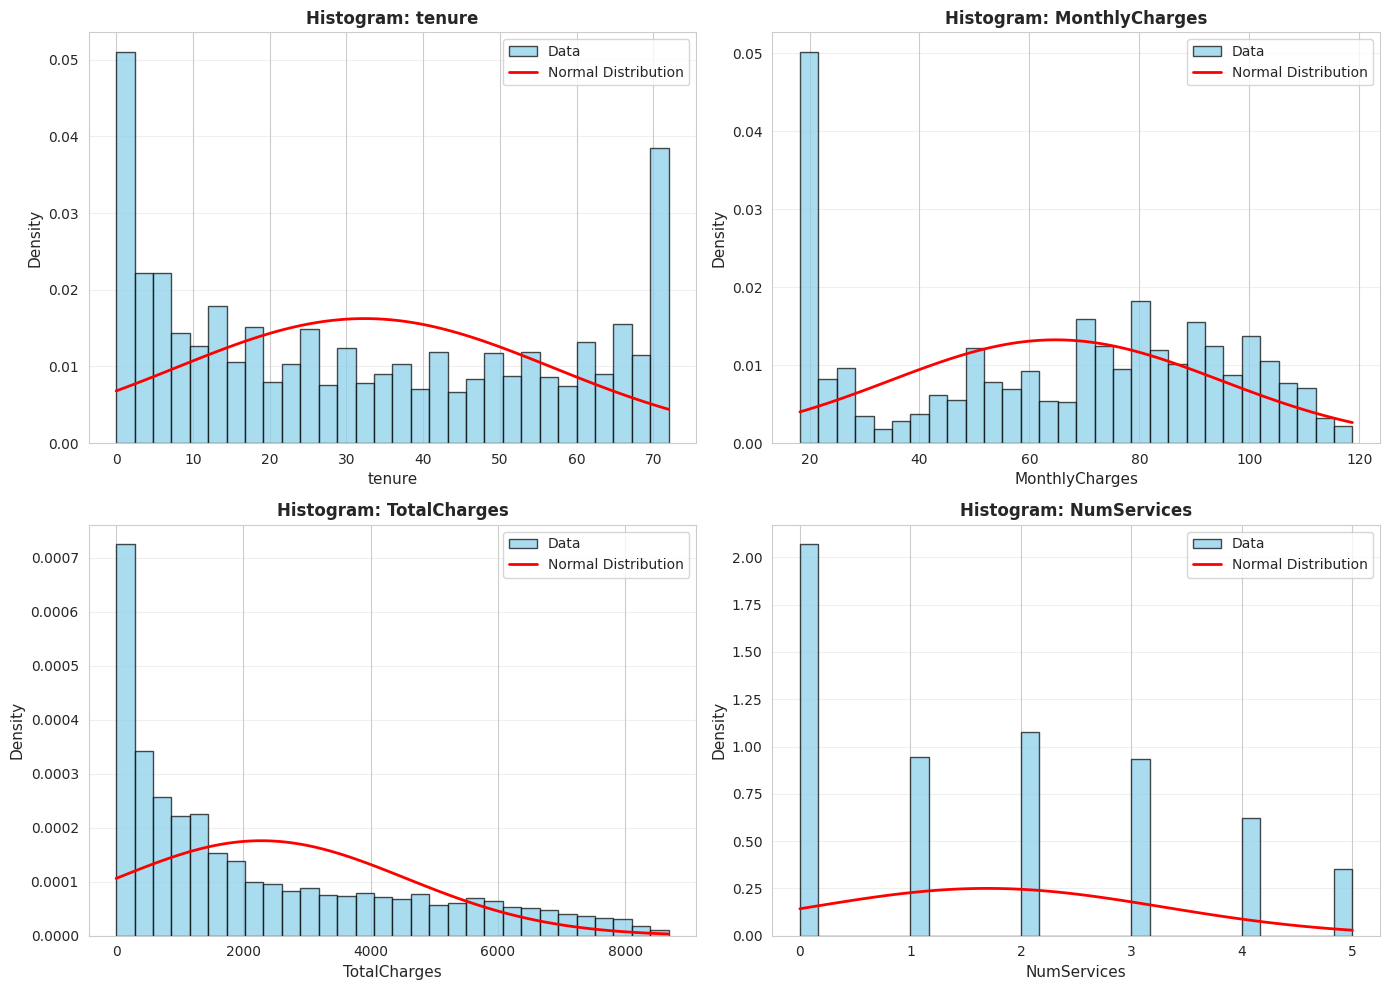


✓ Histograms with normal distribution overlay created


/tmp/ipykernel_13318/3773130538.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_final[feature]], labels=[feature], patch_artist=True, widths=0.5)
/tmp/ipykernel_13318/3773130538.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_final[feature]], labels=[feature], patch_artist=True, widths=0.5)
/tmp/ipykernel_13318/3773130538.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_final[feature]], labels=[feature], patch_artist=True, widths=0.5)
/tmp/ipykernel_13318/3773130538.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has bee

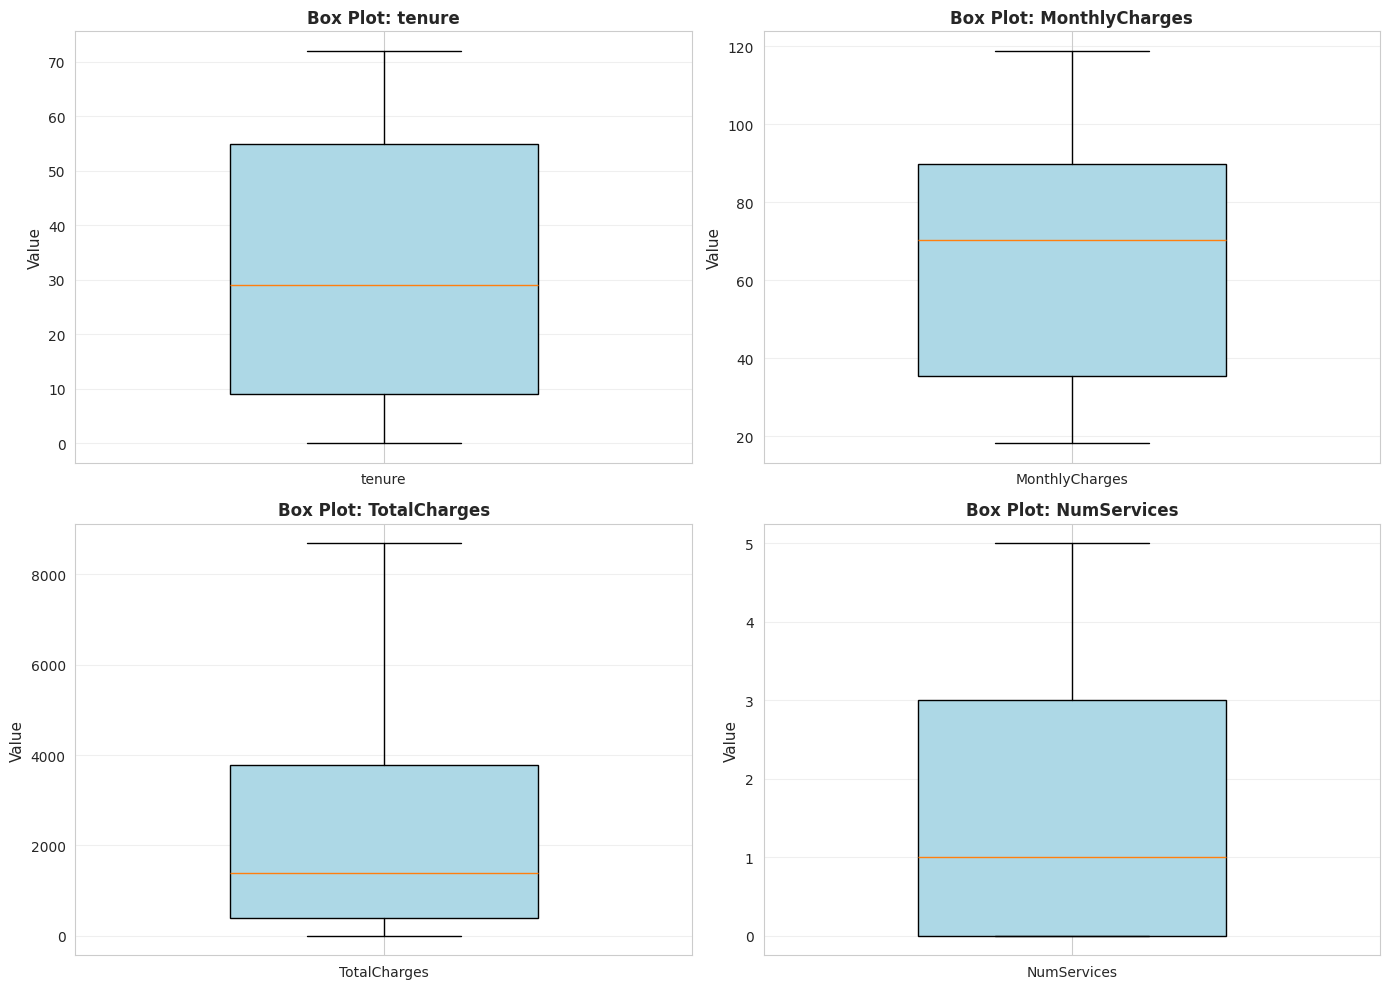

✓ Box plots created

------------------------------------------------------------
NORMALITY TESTS (Shapiro-Wilk Test)
------------------------------------------------------------
Null Hypothesis: Data is normally distributed
p-value > 0.05: Fail to reject H0 (likely normal)
p-value < 0.05: Reject H0 (likely NOT normal)

tenure               | Statistic: 0.903727 | p-value: 7.527284e-55 | ✗ NOT Normal
MonthlyCharges       | Statistic: 0.920889 | p-value: 2.229564e-51 | ✗ NOT Normal
TotalCharges         | Statistic: 0.860151 | p-value: 8.938367e-62 | ✗ NOT Normal
NumServices          | Statistic: 0.870001 | p-value: 2.183658e-60 | ✗ NOT Normal

------------------------------------------------------------
SUMMARY
------------------------------------------------------------


/workspaces/136615906/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)


,Feature,Statistic,p-value,Is_Normal
0,tenure,0.903727,7.527284e-55,False
1,MonthlyCharges,0.920889,2.229564e-51,False
2,TotalCharges,0.860151,8.938367e-62,False
3,NumServices,0.870001,2.183658e-60,False



------------------------------------------------------------
SKEWNESS & KURTOSIS ANALYSIS
------------------------------------------------------------
Skewness: How asymmetric is the distribution?
  Near 0: Symmetric | > 0: Right-skewed | < 0: Left-skewed

Kurtosis: How heavy are the tails?
  Near 0: Normal tails | > 0: Heavy tails | < 0: Light tails

tenure               | Skewness:   0.2395 | Kurtosis:  -1.3872
MonthlyCharges       | Skewness:  -0.2205 | Kurtosis:  -1.2572
TotalCharges         | Skewness:   0.9630 | Kurtosis:  -0.2293
NumServices          | Skewness:   0.5013 | Kurtosis:  -0.9424

✓ Normality Analysis Complete


In [9]:
# ===== NORMALITY ANALYSIS =====
from scipy import stats

print("\n" + "=" * 60)
print("NORMALITY ANALYSIS")
print("=" * 60)

# Select numeric features (excluding encoded categoricals)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices']

# 1. Histograms with Normal Distribution Overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]
    data = df_final[feature]

    # Plot histogram
    ax.hist(data, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Data')

    # Overlay normal distribution
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')

    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Histogram: {feature}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Histograms with normal distribution overlay created")

# 2. Box Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    ax = axes[idx]

    # Create box plot
    bp = ax.boxplot([df_final[feature]], labels=[feature], patch_artist=True, widths=0.5)

    # Color the box
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')

    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Box Plot: {feature}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Box plots created")

# 3. Normality Tests (Shapiro-Wilk Test)
print("\n" + "-" * 60)
print("NORMALITY TESTS (Shapiro-Wilk Test)")
print("-" * 60)
print("Null Hypothesis: Data is normally distributed")
print("p-value > 0.05: Fail to reject H0 (likely normal)")
print("p-value < 0.05: Reject H0 (likely NOT normal)\n")

normality_results = []
for feature in numeric_features:
    stat, p_value = stats.shapiro(df_final[feature])
    is_normal = "✓ Normal" if p_value > 0.05 else "✗ NOT Normal"
    print(f"{feature:20} | Statistic: {stat:.6f} | p-value: {p_value:.6e} | {is_normal}")
    normality_results.append({'Feature': feature, 'Statistic': stat, 'p-value': p_value, 'Is_Normal': p_value > 0.05})

normality_df = pd.DataFrame(normality_results)
print("\n" + "-" * 60)
print("SUMMARY")
print("-" * 60)
display(normality_df.style.format({'Statistic': '{:.6f}', 'p-value': '{:.6e}'}))

# 4. Distribution Characteristics
print("\n" + "-" * 60)
print("SKEWNESS & KURTOSIS ANALYSIS")
print("-" * 60)
print("Skewness: How asymmetric is the distribution?")
print("  Near 0: Symmetric | > 0: Right-skewed | < 0: Left-skewed\n")
print("Kurtosis: How heavy are the tails?")
print("  Near 0: Normal tails | > 0: Heavy tails | < 0: Light tails\n")

for feature in numeric_features:
    data = df_final[feature]
    skewness = stats.skew(data)
    kurtosis = stats.kurtosis(data)
    print(f"{feature:20} | Skewness: {skewness:8.4f} | Kurtosis: {kurtosis:8.4f}")

print("\n" + "=" * 60)
print("✓ Normality Analysis Complete")
print("=" * 60)

In [10]:
# ===== STEP 3: FEATURE ENGINEERING =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("\n" + "=" * 60)
print("STEP 3: FEATURE ENGINEERING")
print("=" * 60)

# Work on a copy
df_fe = df_final.copy()

# Restore human-readable categorical labels where possible
contract_reverse = {0: 'Month-to-month', 1: 'One year', 2: 'Two year'}
internet_reverse = {0: 'DSL', 1: 'Fiber optic', 2: 'No'}
if isinstance(encoding_info.get('PaymentMethod'), dict):
    payment_reverse = {v: k for k, v in encoding_info['PaymentMethod'].items()}
else:
    payment_reverse = {}

# Map back to labels
if 'Contract' in df_fe.columns:
    df_fe['Contract'] = df_fe['Contract'].map(contract_reverse)
if 'InternetService' in df_fe.columns:
    df_fe['InternetService'] = df_fe['InternetService'].map(internet_reverse)
if payment_reverse:
    df_fe['PaymentMethod'] = df_fe['PaymentMethod'].map(payment_reverse)

# 1) Feature: Average monthly spend (safely handle tenure==0)
df_fe['AvgMonthlySpend'] = df_fe.apply(
    lambda r: (r['TotalCharges'] / r['tenure']) if r['tenure'] > 0 else r['MonthlyCharges'],
    axis=1
)

# 2) Tenure bins (useful for analysis, but drop before modeling)
df_fe['TenureGroup'] = pd.cut(df_fe['tenure'], bins=[0,6,12,24,72], labels=['0-6 mo','7-12 mo','13-24 mo','25+ mo'])

# 3) One-hot encode categorical variables (drop_first to avoid dummy trap for linear models)
cat_cols = [c for c in ['Contract', 'InternetService', 'PaymentMethod'] if c in df_fe.columns]
df_model = pd.get_dummies(df_fe, columns=cat_cols, drop_first=True)

# 4) Drop TenureGroup (categorical, not needed for modeling; we have tenure as numeric)
if 'TenureGroup' in df_model.columns:
    df_model = df_model.drop(columns=['TenureGroup'])

# 5) Prepare X and y
y = df_model['Churn']
X = df_model.drop(columns=['Churn'])

# 6) Train/test split (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7) Standardize numeric features (fit scaler on train only)
num_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlySpend'] if c in X_train.columns]
scaler = StandardScaler()
X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test.loc[:, num_cols])

# 8) Summary
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True).map(lambda x: f'{x:.3f}')}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True).map(lambda x: f'{x:.3f}')}")

# Store for later cells
df_fe_final = df_model.copy()
feature_columns = X_train.columns.tolist()

print(f"\nFeatures used for modeling ({len(feature_columns)}):")
print(feature_columns)

print('\nSample engineered features (before standardization):')
display(df_fe[['tenure','MonthlyCharges','TotalCharges','AvgMonthlySpend','TenureGroup','NumServices']].head())
print('\n✓ Feature engineering complete - ready for modeling')


STEP 3: FEATURE ENGINEERING
X_train shape: (5634, 12)
X_test shape:  (1409, 12)
y_train distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: object
y_test distribution:
Churn
0    0.735
1    0.265
Name: proportion, dtype: object

Features used for modeling (12):
['tenure', 'MonthlyCharges', 'TotalCharges', 'NumServices', 'AvgMonthlySpend', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Sample engineered features (before standardization):


/tmp/ipykernel_13318/2732587063.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.10237124 -0.71174346 -0.79315493 ... -0.30468611 -0.34539184
 -1.07809507]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
/tmp/ipykernel_13318/2732587063.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.80691741 -0.44117392  0.18287174 ...  0.80691741 -1.06521959
 -1.06521959]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
/tmp/ipykernel_13318/2732587063.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.60848343 -0.9966836   0.34660565 ... -1

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,TenureGroup,NumServices
0,1,29.85,29.85,29.850000,0-6 mo,0
1,34,56.95,1889.50,55.573529,25+ mo,2
2,2,53.85,108.15,54.075000,0-6 mo,1
3,45,42.30,1840.75,40.905556,25+ mo,3
4,2,70.70,151.65,75.825000,0-6 mo,0



✓ Feature engineering complete - ready for modeling



STEP 4: MODELING

🔵 MODEL 1: LOGISTIC REGRESSION (BASELINE)
------------------------------------------------------------

Training Logistic Regression...

✓ Logistic Regression Trained

PERFORMANCE METRICS
Accuracy:  0.7991
Precision: 0.6454  (of predicted churners, how many actually churned?)
Recall:    0.5401    (of actual churners, how many did we catch?)
F1-Score:  0.5881     (harmonic mean of precision & recall)
ROC-AUC:   0.8355     (probability curve, 1.0 = perfect, 0.5 = random)

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409


----------------------------------

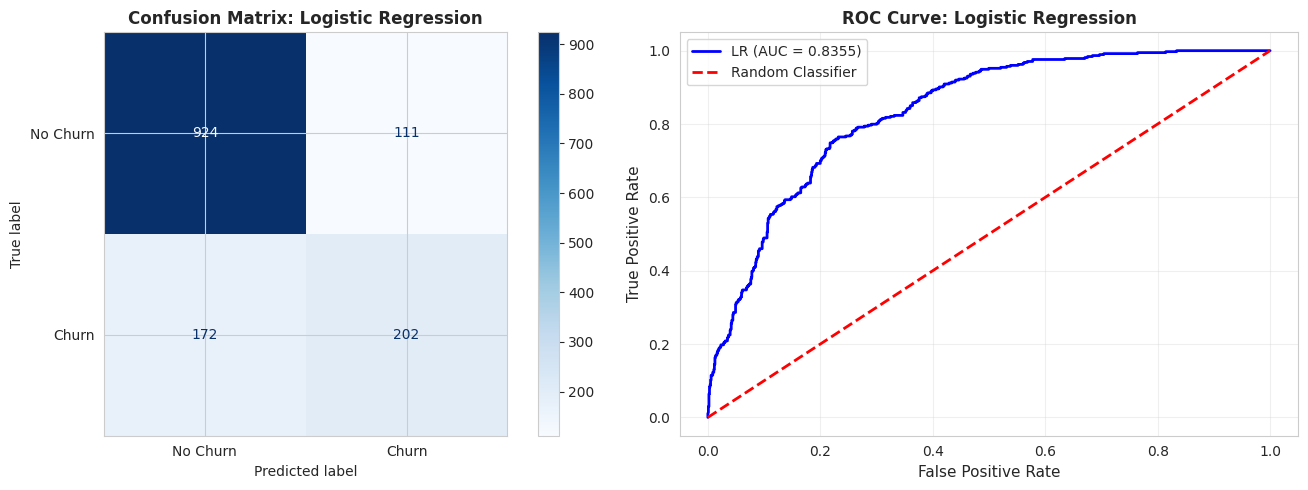


------------------------------------------------------------
FEATURE IMPORTANCE (Coefficients)
------------------------------------------------------------

Top 10 Most Impactful Features:


,Feature,Coefficient
6,Contract_Two year,-1.589852
0,tenure,-1.231966
7,InternetService_Fiber optic,1.000716
8,InternetService_No,-0.904246
5,Contract_One year,-0.822293
2,TotalCharges,0.561892
11,PaymentMethod_Mailed check,-0.542602
10,PaymentMethod_Electronic check,-0.515331
9,PaymentMethod_Credit card (automatic),-0.513105
4,AvgMonthlySpend,-0.071174



✓ Logistic Regression Baseline Complete


In [11]:
# ===== STEP 4: MODELING - LOGISTIC REGRESSION (BASELINE) =====
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("\n" + "=" * 60)
print("STEP 4: MODELING")
print("=" * 60)
print("\n🔵 MODEL 1: LOGISTIC REGRESSION (BASELINE)")
print("-" * 60)

# Initialize and train
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print("\n✓ Logistic Regression Trained")
print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}  (of predicted churners, how many actually churned?)")
print(f"Recall:    {lr_recall:.4f}    (of actual churners, how many did we catch?)")
print(f"F1-Score:  {lr_f1:.4f}     (harmonic mean of precision & recall)")
print(f"ROC-AUC:   {lr_roc_auc:.4f}     (probability curve, 1.0 = perfect, 0.5 = random)")

# Classification Report
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\n" + "-" * 60)
print("CONFUSION MATRIX")
print("-" * 60)
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"True Negatives:  {cm_lr[0,0]:5d}  (correctly predicted no churn)")
print(f"False Positives: {cm_lr[0,1]:5d}  (incorrectly predicted churn)")
print(f"False Negatives: {cm_lr[1,0]:5d}  (missed actual churners) ⚠️")
print(f"True Positives:  {cm_lr[1,1]:5d}  (correctly predicted churn)")

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix: Logistic Regression', fontsize=12, fontweight='bold')

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lr)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'LR (AUC = {lr_roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve: Logistic Regression', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance (coefficients)
print("\n" + "-" * 60)
print("FEATURE IMPORTANCE (Coefficients)")
print("-" * 60)
feature_importance_lr = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Most Impactful Features:")
display(feature_importance_lr.head(10).style.format({'Coefficient': '{:.6f}'}))

# Store for comparison
lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'ROC-AUC': lr_roc_auc,
    'Model_Object': lr_model
}

print("\n" + "=" * 60)
print("✓ Logistic Regression Baseline Complete")
print("=" * 60)


🟢 MODEL 2: RANDOM FOREST (FINAL MODEL)
------------------------------------------------------------

Training Random Forest...

✓ Random Forest Trained

PERFORMANCE METRICS
Accuracy:  0.7736
Precision: 0.5572  (of predicted churners, how many actually churned?)
Recall:    0.7166    (of actual churners, how many did we catch?)
F1-Score:  0.6269     (harmonic mean of precision & recall)
ROC-AUC:   0.8404     (probability curve, 1.0 = perfect, 0.5 = random)

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


------------------------------------------------------------
CONFUS

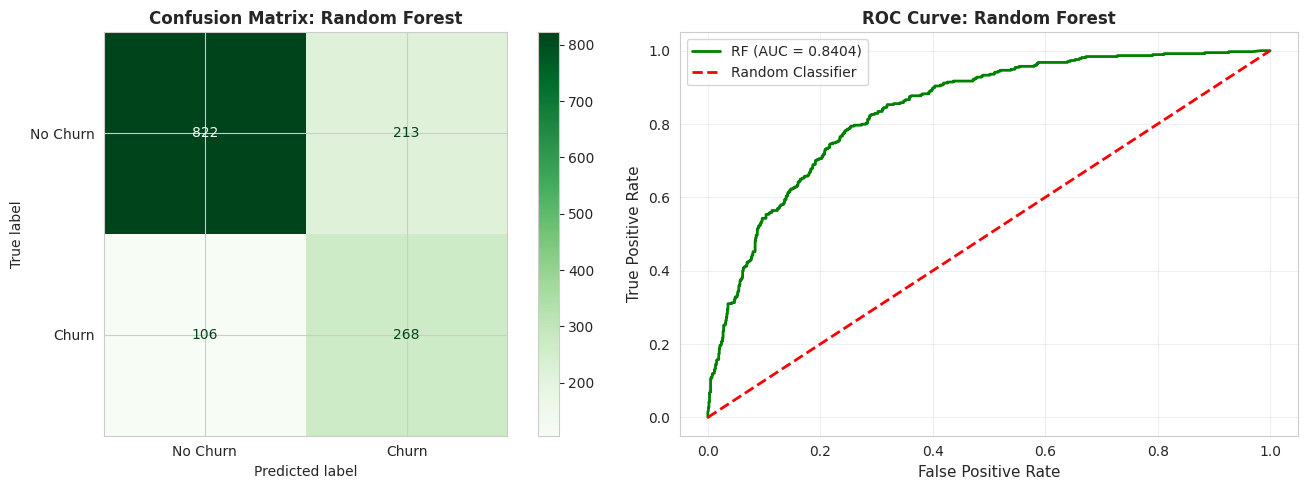


------------------------------------------------------------
FEATURE IMPORTANCE (Mean Decrease in Impurity)
------------------------------------------------------------

Top 10 Most Important Features:


,Feature,Importance
0,tenure,0.204416
2,TotalCharges,0.167498
1,MonthlyCharges,0.148209
4,AvgMonthlySpend,0.132574
6,Contract_Two year,0.113883
7,InternetService_Fiber optic,0.079355
5,Contract_One year,0.047682
8,InternetService_No,0.040108
3,NumServices,0.030273
10,PaymentMethod_Electronic check,0.014052



✓ Random Forest Final Model Complete

MODEL COMPARISON: BASELINE vs FINAL




,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7991,0.6454,0.5401,0.5881,0.8355
1,Random Forest,0.7736,0.5572,0.7166,0.6269,0.8404



------------------------------------------------------------
IMPROVEMENT METRICS
------------------------------------------------------------
Accuracy improvement:  -0.0256 (-3.20%)
Recall improvement:    0.1765 (32.67%)
F1-Score improvement:  0.0388 (6.60%)
ROC-AUC improvement:   0.0049 (0.58%)

✓ Model Comparison Complete


In [12]:
# ===== STEP 4: MODELING - RANDOM FOREST (FINAL MODEL) =====
from sklearn.ensemble import RandomForestClassifier

print("\n" + "=" * 60)
print("🟢 MODEL 2: RANDOM FOREST (FINAL MODEL)")
print("-" * 60)

# Initialize and train
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("\n✓ Random Forest Trained")
print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}  (of predicted churners, how many actually churned?)")
print(f"Recall:    {rf_recall:.4f}    (of actual churners, how many did we catch?)")
print(f"F1-Score:  {rf_f1:.4f}     (harmonic mean of precision & recall)")
print(f"ROC-AUC:   {rf_roc_auc:.4f}     (probability curve, 1.0 = perfect, 0.5 = random)")

# Classification Report
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\n" + "-" * 60)
print("CONFUSION MATRIX")
print("-" * 60)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"True Negatives:  {cm_rf[0,0]:5d}  (correctly predicted no churn)")
print(f"False Positives: {cm_rf[0,1]:5d}  (incorrectly predicted churn)")
print(f"False Negatives: {cm_rf[1,0]:5d}  (missed actual churners) ⚠️")
print(f"True Positives:  {cm_rf[1,1]:5d}  (correctly predicted churn)")

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax1, cmap='Greens', values_format='d')
ax1.set_title('Confusion Matrix: Random Forest', fontsize=12, fontweight='bold')

# ROC Curve
ax2 = axes[1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
ax2.plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'RF (AUC = {rf_roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve: Random Forest', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance (impurity-based)
print("\n" + "-" * 60)
print("FEATURE IMPORTANCE (Mean Decrease in Impurity)")
print("-" * 60)
feature_importance_rf = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
display(feature_importance_rf.head(10).style.format({'Importance': '{:.6f}'}))

# Store for comparison
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'ROC-AUC': rf_roc_auc,
    'Model_Object': rf_model
}

print("\n" + "=" * 60)
print("✓ Random Forest Final Model Complete")
print("=" * 60)

# ===== MODEL COMPARISON =====
print("\n" + "=" * 60)
print("MODEL COMPARISON: BASELINE vs FINAL")
print("=" * 60)

comparison_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': lr_accuracy,
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1-Score': lr_f1,
        'ROC-AUC': lr_roc_auc
    },
    {
        'Model': 'Random Forest',
        'Accuracy': rf_accuracy,
        'Precision': rf_precision,
        'Recall': rf_recall,
        'F1-Score': rf_f1,
        'ROC-AUC': rf_roc_auc
    }
])

print("\n")
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], color='lightgreen'))

# Calculate improvements
print("\n" + "-" * 60)
print("IMPROVEMENT METRICS")
print("-" * 60)
print(f"Accuracy improvement:  {(rf_accuracy - lr_accuracy):.4f} ({((rf_accuracy - lr_accuracy) / lr_accuracy * 100):.2f}%)")
print(f"Recall improvement:    {(rf_recall - lr_recall):.4f} ({((rf_recall - lr_recall) / lr_recall * 100):.2f}%)")
print(f"F1-Score improvement:  {(rf_f1 - lr_f1):.4f} ({((rf_f1 - lr_f1) / lr_f1 * 100):.2f}%)")
print(f"ROC-AUC improvement:   {(rf_roc_auc - lr_roc_auc):.4f} ({((rf_roc_auc - lr_roc_auc) / lr_roc_auc * 100):.2f}%)")

print("\n" + "=" * 60)
print("✓ Model Comparison Complete")
print("=" * 60)


🟡 MODEL 3: XGBOOST (BENCHMARK MODEL)
------------------------------------------------------------

Training XGBoost...

✓ XGBoost Trained

PERFORMANCE METRICS
Accuracy:  0.7580
Precision: 0.5313  (of predicted churners, how many actually churned?)
Recall:    0.7487    (of actual churners, how many did we catch?)
F1-Score:  0.6215     (harmonic mean of precision & recall)
ROC-AUC:   0.8347     (probability curve, 1.0 = perfect, 0.5 = random)

------------------------------------------------------------
CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


------------------------------------------------------------
CONFUSION MATRIX
---

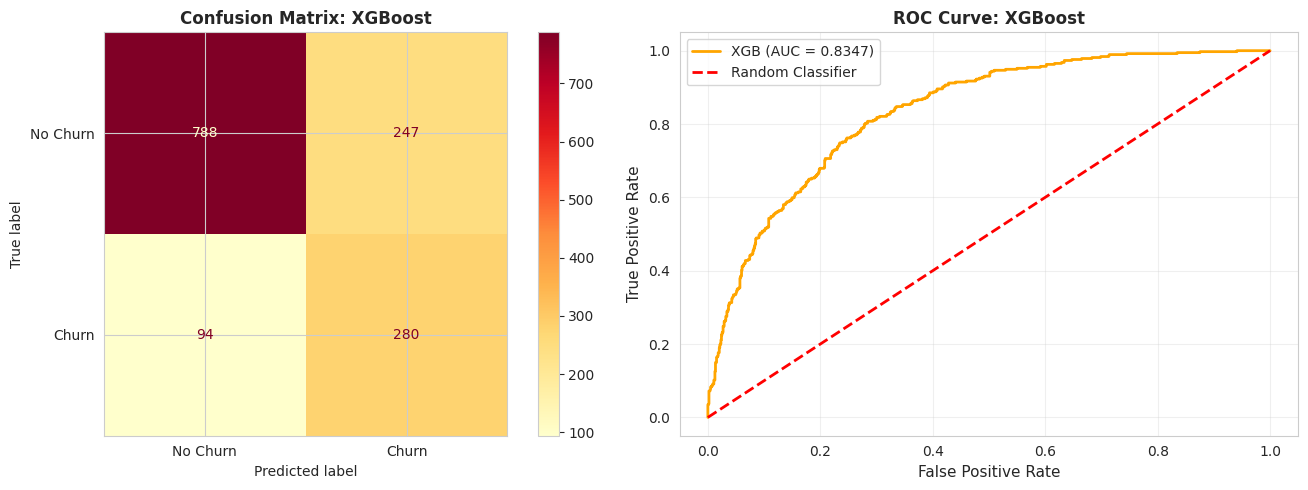


------------------------------------------------------------
FEATURE IMPORTANCE (Gain-based)
------------------------------------------------------------

Top 10 Most Important Features:


,Feature,Importance
6,Contract_Two year,0.393221
7,InternetService_Fiber optic,0.262246
5,Contract_One year,0.120774
8,InternetService_No,0.094400
0,tenure,0.024216
2,TotalCharges,0.019735
9,PaymentMethod_Credit card (automatic),0.016052
1,MonthlyCharges,0.014800
3,NumServices,0.014623
10,PaymentMethod_Electronic check,0.014045



✓ XGBoost Benchmark Model Complete

COMPREHENSIVE MODEL COMPARISON: ALL 3 MODELS




,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7991,0.6454,0.5401,0.5881,0.8355
1,Random Forest,0.7736,0.5572,0.7166,0.6269,0.8404
2,XGBoost,0.7580,0.5313,0.7487,0.6215,0.8347



------------------------------------------------------------
BEST MODEL BY METRIC
------------------------------------------------------------
Accuracy        → Logistic Regression  (0.7991)
Precision       → Logistic Regression  (0.6454)
Recall          → XGBoost              (0.7487)
F1-Score        → Random Forest        (0.6269)
ROC-AUC         → Random Forest        (0.8404)

------------------------------------------------------------
Creating comparison visualizations...
------------------------------------------------------------


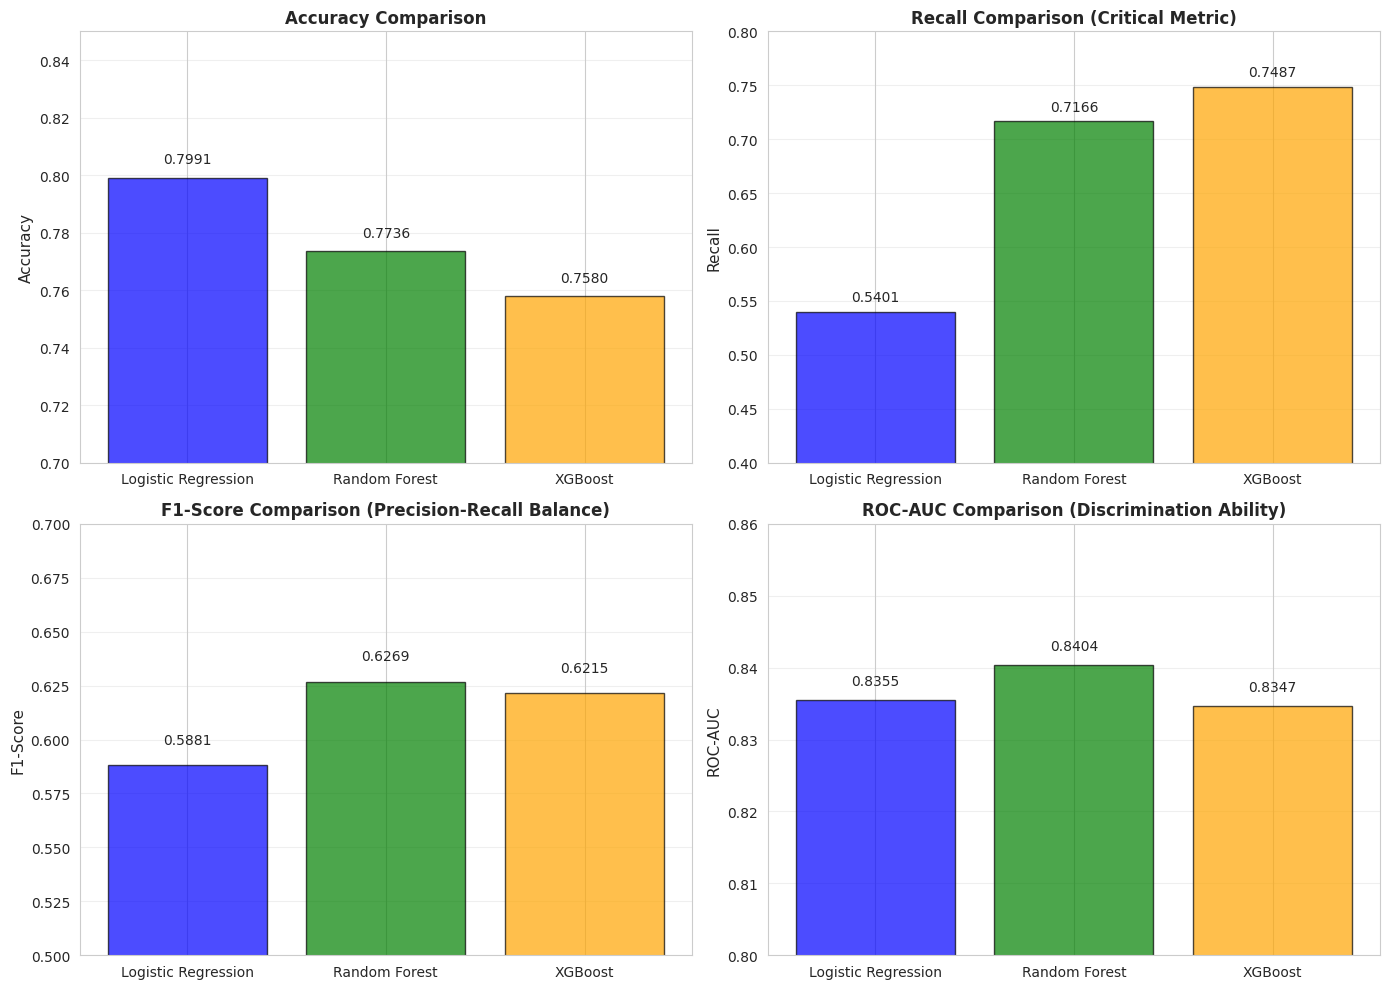

Creating combined ROC curve...


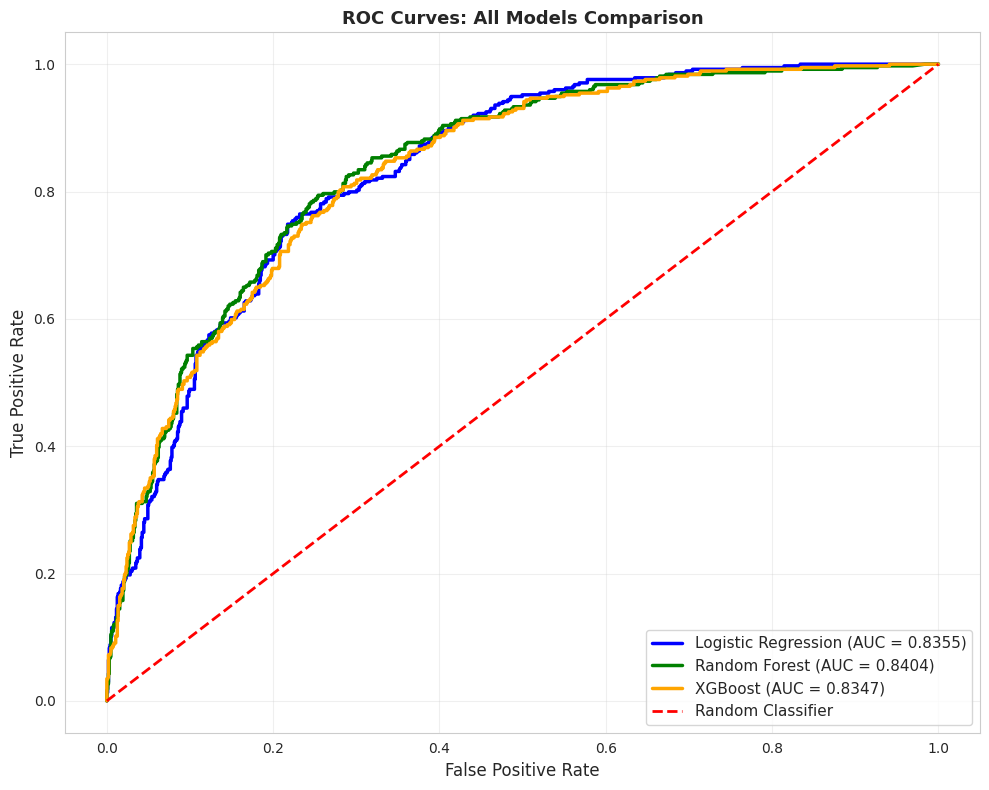


✓ COMPREHENSIVE MODEL COMPARISON COMPLETE


In [13]:
# ===== STEP 4: MODELING - XGBOOST (BENCHMARK MODEL) =====
from xgboost import XGBClassifier

print("\n" + "=" * 60)
print("🟡 MODEL 3: XGBOOST (BENCHMARK MODEL)")
print("-" * 60)

# Initialize and train
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])  # Balance classes
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n✓ XGBoost Trained")
print("\n" + "=" * 60)
print("PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}  (of predicted churners, how many actually churned?)")
print(f"Recall:    {xgb_recall:.4f}    (of actual churners, how many did we catch?)")
print(f"F1-Score:  {xgb_f1:.4f}     (harmonic mean of precision & recall)")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}     (probability curve, 1.0 = perfect, 0.5 = random)")

# Classification Report
print("\n" + "-" * 60)
print("CLASSIFICATION REPORT")
print("-" * 60)
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

# Confusion Matrix
print("\n" + "-" * 60)
print("CONFUSION MATRIX")
print("-" * 60)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"True Negatives:  {cm_xgb[0,0]:5d}  (correctly predicted no churn)")
print(f"False Positives: {cm_xgb[0,1]:5d}  (incorrectly predicted churn)")
print(f"False Negatives: {cm_xgb[1,0]:5d}  (missed actual churners) ⚠️")
print(f"True Positives:  {cm_xgb[1,1]:5d}  (correctly predicted churn)")

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
ax1 = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax1, cmap='YlOrRd', values_format='d')
ax1.set_title('Confusion Matrix: XGBoost', fontsize=12, fontweight='bold')

# ROC Curve
ax2 = axes[1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
ax2.plot(fpr_xgb, tpr_xgb, color='orange', linewidth=2, label=f'XGB (AUC = {xgb_roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve: XGBoost', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature Importance (tree-based)
print("\n" + "-" * 60)
print("FEATURE IMPORTANCE (Gain-based)")
print("-" * 60)
feature_importance_xgb = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
display(feature_importance_xgb.head(10).style.format({'Importance': '{:.6f}'}))

# Store for comparison
xgb_results = {
    'Model': 'XGBoost',
    'Accuracy': xgb_accuracy,
    'Precision': xgb_precision,
    'Recall': xgb_recall,
    'F1-Score': xgb_f1,
    'ROC-AUC': xgb_roc_auc,
    'Model_Object': xgb_model
}

print("\n" + "=" * 60)
print("✓ XGBoost Benchmark Model Complete")
print("=" * 60)

# ===== COMPREHENSIVE MODEL COMPARISON (ALL 3 MODELS) =====
print("\n" + "=" * 60)
print("COMPREHENSIVE MODEL COMPARISON: ALL 3 MODELS")
print("=" * 60)

comparison_df_all = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': lr_accuracy,
        'Precision': lr_precision,
        'Recall': lr_recall,
        'F1-Score': lr_f1,
        'ROC-AUC': lr_roc_auc
    },
    {
        'Model': 'Random Forest',
        'Accuracy': rf_accuracy,
        'Precision': rf_precision,
        'Recall': rf_recall,
        'F1-Score': rf_f1,
        'ROC-AUC': rf_roc_auc
    },
    {
        'Model': 'XGBoost',
        'Accuracy': xgb_accuracy,
        'Precision': xgb_precision,
        'Recall': xgb_recall,
        'F1-Score': xgb_f1,
        'ROC-AUC': xgb_roc_auc
    }
])

print("\n")
display(comparison_df_all.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], color='lightgreen'))

# Comparative analysis
print("\n" + "-" * 60)
print("BEST MODEL BY METRIC")
print("-" * 60)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for metric in metrics:
    best_model = comparison_df_all.loc[comparison_df_all[metric].idxmax(), 'Model']
    best_value = comparison_df_all[metric].max()
    print(f"{metric:15} → {best_model:20} ({best_value:.4f})")

# Visualization: Compare all models across metrics
print("\n" + "-" * 60)
print("Creating comparison visualizations...")
print("-" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy comparison
ax1 = axes[0, 0]
models = comparison_df_all['Model'].tolist()
accuracies = comparison_df_all['Accuracy'].tolist()
colors = ['blue', 'green', 'orange']
ax1.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim([0.7, 0.85])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)

# 2. Recall comparison (critical for churn)
ax2 = axes[0, 1]
recalls = comparison_df_all['Recall'].tolist()
ax2.bar(models, recalls, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Recall', fontsize=11)
ax2.set_title('Recall Comparison (Critical Metric)', fontsize=12, fontweight='bold')
ax2.set_ylim([0.4, 0.8])
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(recalls):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# 3. F1-Score comparison
ax3 = axes[1, 0]
f1_scores = comparison_df_all['F1-Score'].tolist()
ax3.bar(models, f1_scores, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('F1-Score', fontsize=11)
ax3.set_title('F1-Score Comparison (Precision-Recall Balance)', fontsize=12, fontweight='bold')
ax3.set_ylim([0.5, 0.7])
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(f1_scores):
    ax3.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

# 4. ROC-AUC comparison
ax4 = axes[1, 1]
roc_aucs = comparison_df_all['ROC-AUC'].tolist()
ax4.bar(models, roc_aucs, color=colors, alpha=0.7, edgecolor='black')
ax4.set_ylabel('ROC-AUC', fontsize=11)
ax4.set_title('ROC-AUC Comparison (Discrimination Ability)', fontsize=12, fontweight='bold')
ax4.set_ylim([0.8, 0.86])
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(roc_aucs):
    ax4.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ROC Curves: All models together
print("Creating combined ROC curve...")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curves for all three models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

ax.plot(fpr_lr, tpr_lr, 'b-', linewidth=2.5, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
ax.plot(fpr_rf, tpr_rf, 'g-', linewidth=2.5, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')
ax.plot(fpr_xgb, tpr_xgb, color='orange', linewidth=2.5, label=f'XGBoost (AUC = {xgb_roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: All Models Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("✓ COMPREHENSIVE MODEL COMPARISON COMPLETE")
print("=" * 60)

In [14]:
import joblib

# 1. Define the directory/path where you want to save the models
# You can create a 'models' folder to keep things organized
import os
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Save the Scaler (Crucial for transforming new user input)
joblib.dump(scaler, 'models/churn_scaler.joblib')

# 3. Save the trained Models
joblib.dump(lr_model, 'models/logistic_regression_model.joblib')
joblib.dump(rf_model, 'models/random_forest_model.joblib')
joblib.dump(xgb_model, 'models/xgboost_model.joblib')

# 4. Save the Feature Names (To ensure correct input order in Dash)
joblib.dump(feature_columns, 'models/feature_names.joblib')

print("✓ All models and preprocessing artifacts have been saved to the 'models/' directory.")

✓ All models and preprocessing artifacts have been saved to the 'models/' directory.
